In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "v", "<", ">", "s", "X"]

_SNS_PARAMS = {"markers":_MARKERS, "dashes":True, "markersize": 10}

In [84]:
from glob import glob
from os.path import join


tot_dataframe = pd.concat(map(pd.read_csv, glob(join('..', "bench_results_seg_scan_sc_128_*.csv"))))
tot_dataframe["operator"] = "SegScanSingleCore"

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4

tot_dataframe['bandwidth_mbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']) #MB/s
tot_dataframe['bandwidth_gbps'] = tot_dataframe["bandwidth_mbps"] / 1000
tot_dataframe["density"] = ["%s" % x for x in tot_dataframe["density"]]


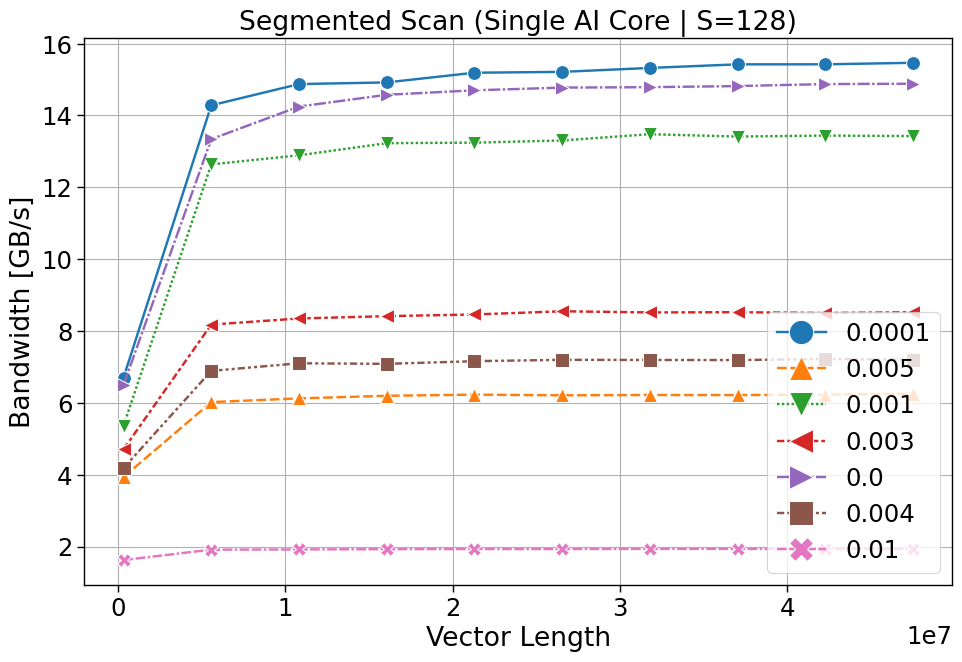

In [86]:

df = tot_dataframe[tot_dataframe["size"] < 5 * 1e7]

plt.figure(figsize=(10, 7))
sns.lineplot(x='size', y='bandwidth_gbps', hue='density', style='density', data=df, **_SNS_PARAMS)

plt.xlabel('Vector Length')
plt.ylabel('Bandwidth [GB/s]')
plt.title('Segmented Scan (Single AI Core | S=128)')
plt.legend(loc="lower right", markerscale=_LEGEND_MARKER_SCALE)
plt.tight_layout()

plt.grid(True)
plt.savefig("segm_scan_sc_s_128.png")
plt.savefig("segm_scan_sc_s_128.pdf")
plt.show()
